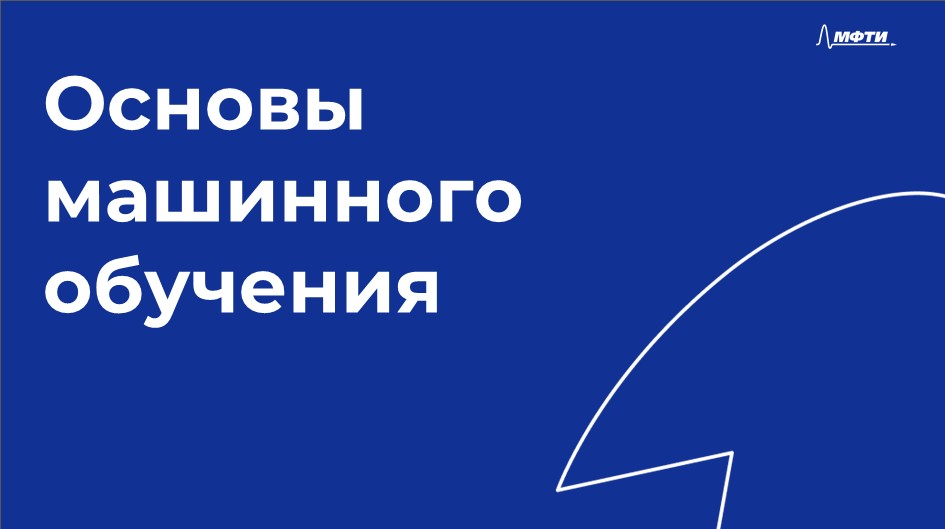

# 🎯 Неделя 3. Семинар 1.

**Сегодня в программе:**

1. От линейной регрессии к логистической.
2. Бинарная классификация и баланс классов.
3. Вероятностные оценки и подбор порога.
4. Многоклассовая классификация и метрики.

## 🟢 1. От линейной регрессии к логистической

**Задача классификации** состоит в предсказании категориального целевого признака на основе признаков объекта.

Существуют два основных типа задачи классификации:

- **Бинарная классификация** — когда число классов равно двум:

  * есть заболевание / нет заболевания;
  * спам / не спам;
  * человек на изображении / нет людей.

- **Многоклассовая классификация** — когда число классов больше двух:

  * определение модели самолёта по снимку;
  * классификация животных на изображениях;
  * распределение писем по темам.


Попробуем из линейной регрессии получить линейную модель классификации.

> Напомним, что в задаче регрессии модель должна наилучшим образом **аппроксимировать зависимость**. В задаче классификации цель - наилучшим образом провести разделяющую линию/плоскость/гиперпроскость между объектами разных классов.
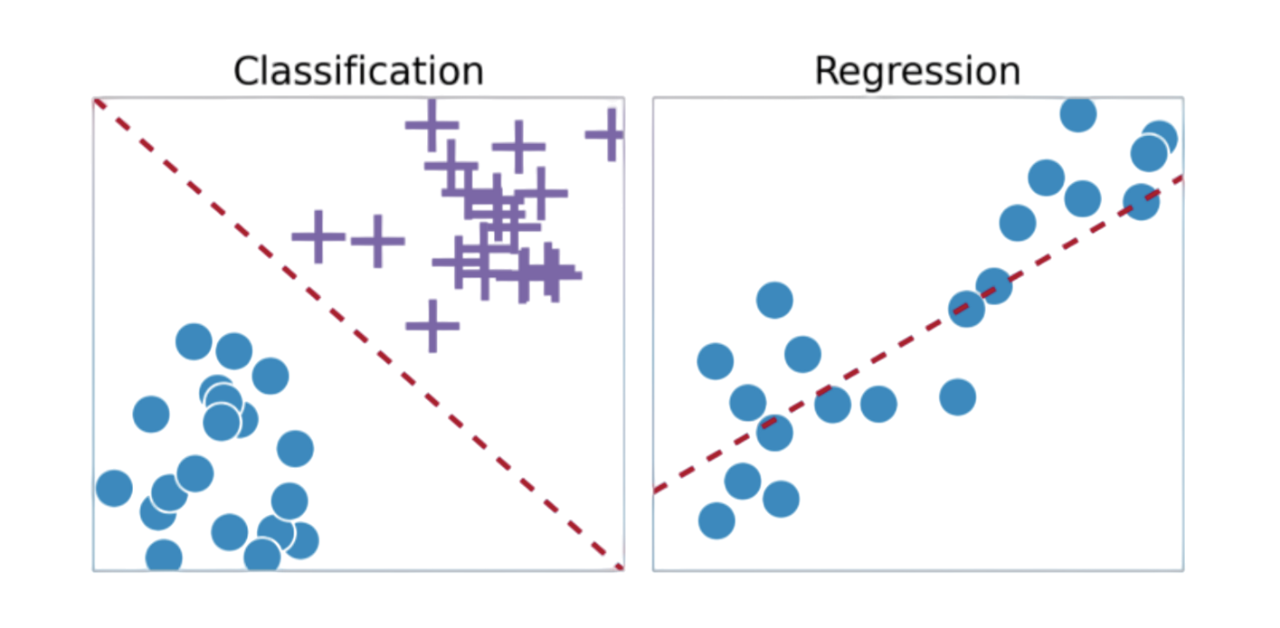





Итак, если в качестве разделяющей поверхности взять прямую, как на рисунке, то мы получим модель логистической регрессии, которая тесно связана с рассмотренной ранее линейной регрессией.

Давайте для начала вспомним, как выглядит уравнение модели линейной регрессии в общем случае:

$$y = k_1x_1 + k_2x_2 + ... + k_nx_n + b$$

Как преобразовать модель, когда целевой признак  является категориальным - например, обычное письмо или спам?

Обозначим категорию "спам" как $y=1$ "не спам" - $y=0$ и обучим линейную регрессию предсказывать 0 и 1.

Но в таком виде результат будет не самый лучший, геометрически ситуация будет выглядеть так:

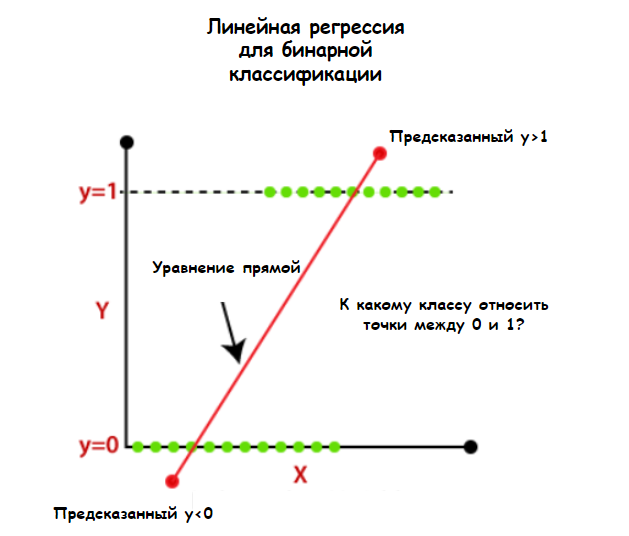

***Все значения будут непрерывны, да еще и выходят за пределы 0 и 1.***

Давайте вместо класса будем предсказывать **оценку принадлежности к классу** в диапазоне $[0, 1]$.

Далее выбирается порог: если значение выше порога — объект относим к классу 1, иначе к классу 0.
Чаще всего используют порог 0.5 (например, спам / не спам).

Таким образом, задача классификации сводится к предсказанию **непрерывного числового значения**, а не дискретной метки.

*Возникает вопрос: как получать значения в диапазоне $[0, 1]$, если линейная регрессия предсказывает числа от $-\infty$ до $+\infty$?*


В основе логистической регрессии лежит логистическая функция (logistic function)  — отсюда и название модели. Однако более распространённое название этой функции — сигмόида (sigmoid):

$$\sigma(x) = \frac{1}{1 + e^{-x}}$$

А вот ее график:

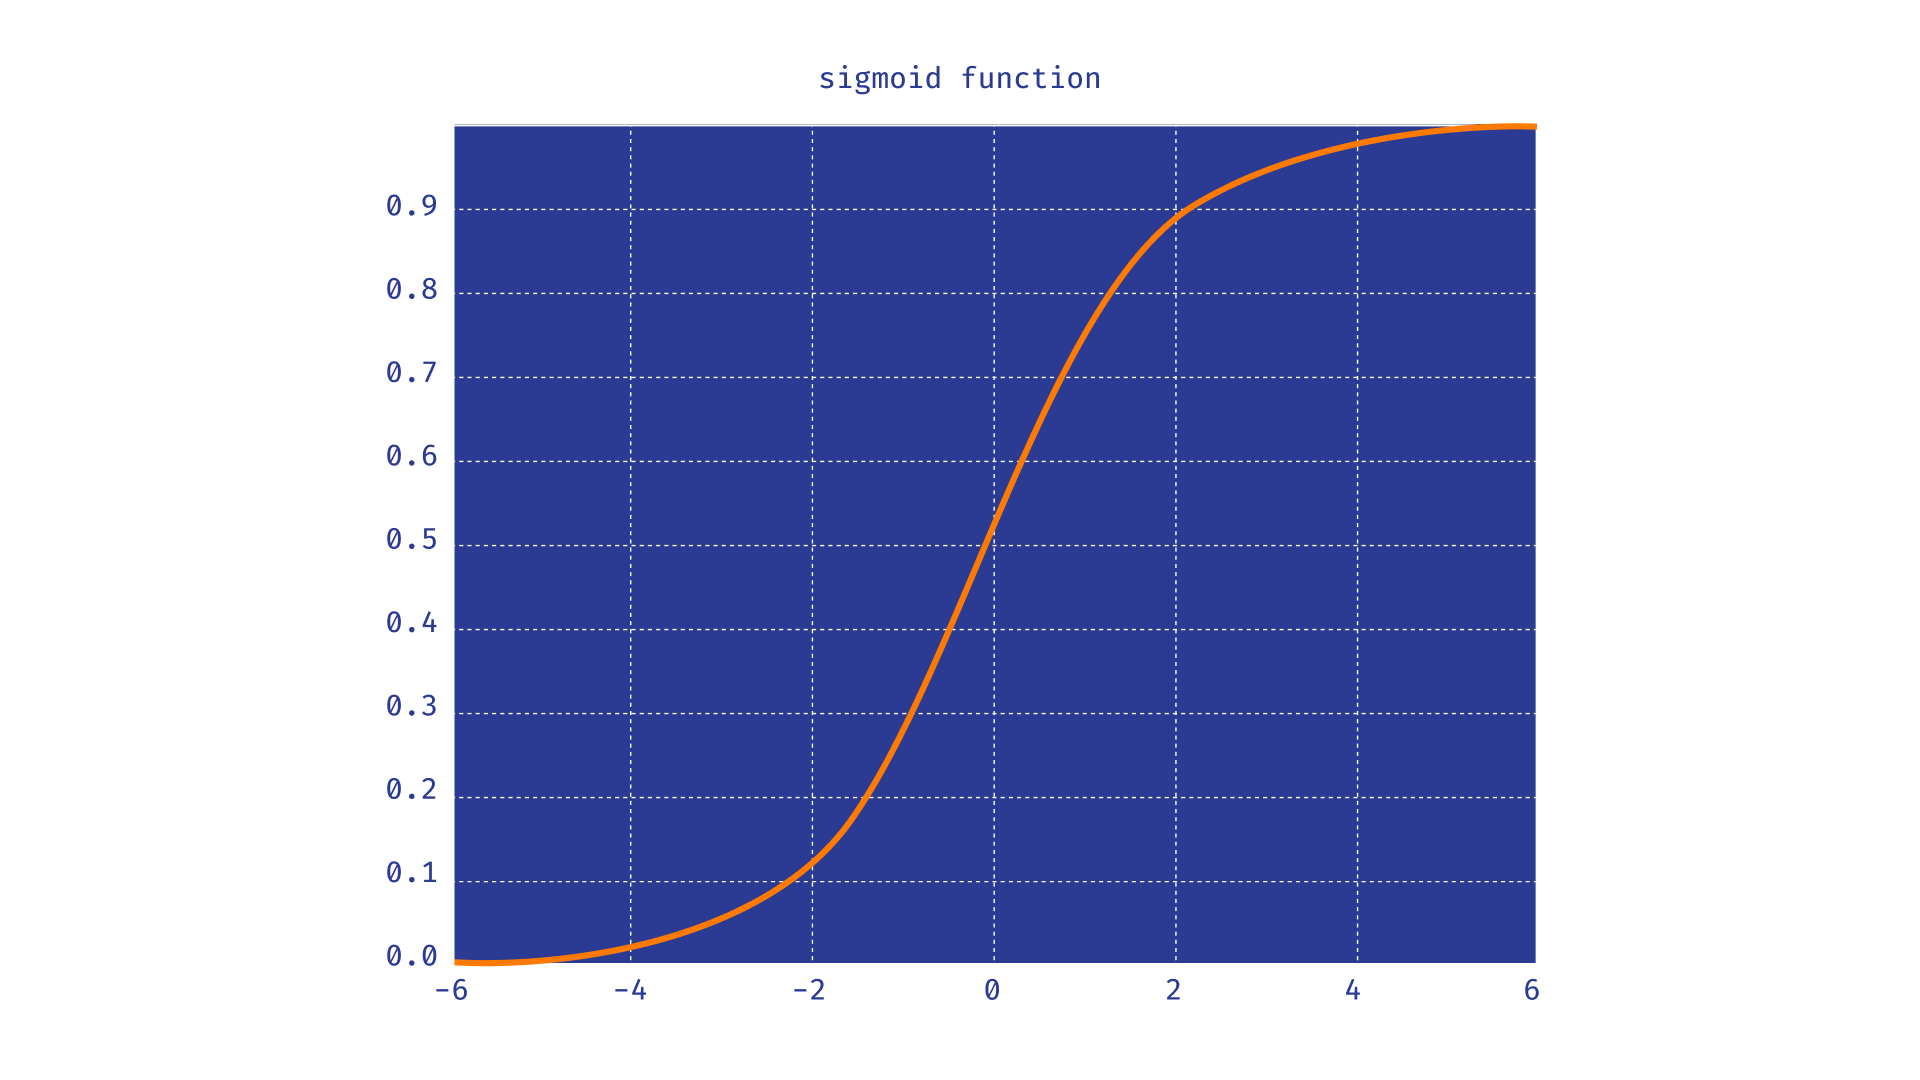

**Сигмоида обладает рядом хороших свойств:**

1. её значения лежат в диапазоне от 0 до 1

2. ось $Y$ график сигмоиды пересекает в точке 0.5

3. функция стремится к 1 на $+\infty$ и к 0 - на $-\infty$

Если подставим выход модели линейной регрессии в функцию сигмоиды - получим искомые оценки вероятности:

$$P(y=1|x) = \frac{1}{1 + e^{-z}},$$

где $z$ - линейная комбинация входных значений $x$ и соответствующих коэффициентов регрессии

Тогда для примера задачи бинарной классификации получим следующую картину:



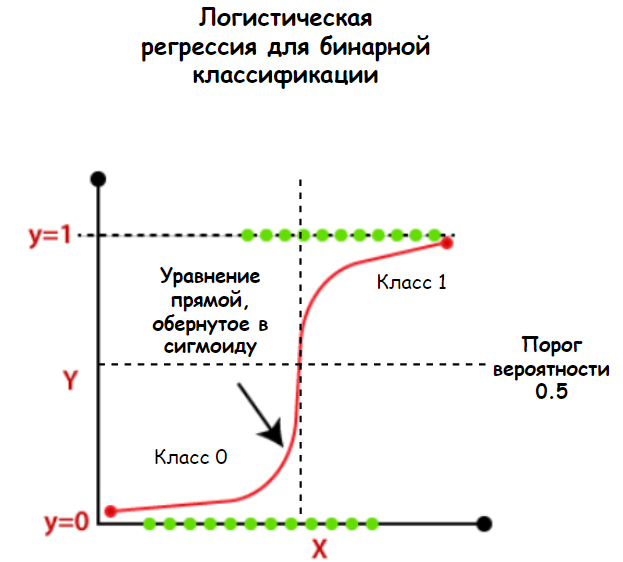

***Рассмотрим пример:*** предсказание поступления студента по результатам двух экзаменов.

Используем логистическую регрессию для оценки вероятности поступления (поступил / не поступил). Объекты изобразим точками в пространстве двух признаков, окрашенными по целевому классу.

Геометрически задача сводится к подбору коэффициентов, которые наилучшим образом разделяют пространство признаков на два класса.


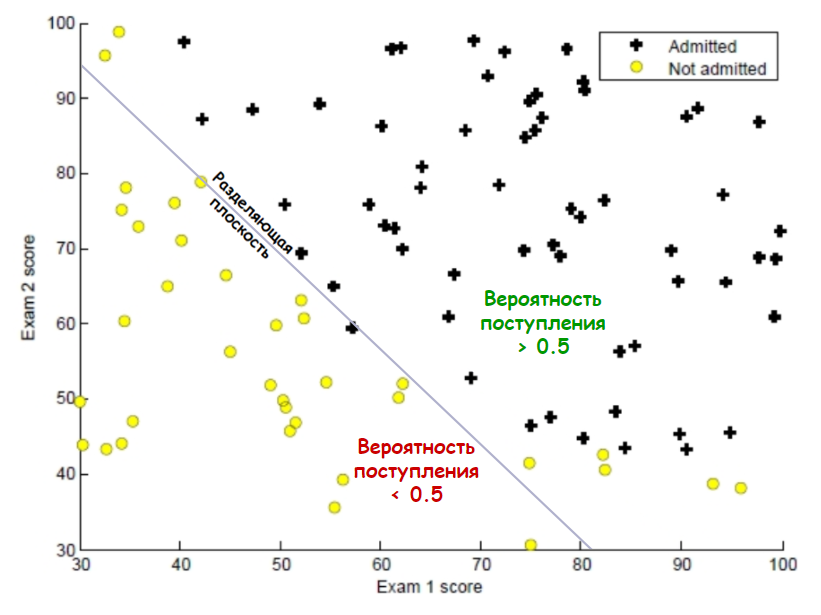

Таким образом, ключевым моментом в предсказании логистической регрессии является расстояние от точки до разделяющей плоскости, его часто называют **отступом (margin)**.

Чем больше расстояние от точки, находящейся выше разделяющей плоскости, до самой плоскости, тем больше оценка вероятности принадлежности к классу 1.

Можно построить тепловую карту, которая показывает, чему равны вероятности:



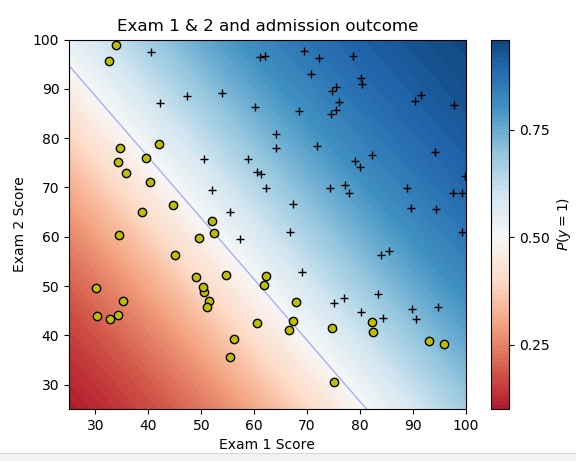

В случае, когда целевой признак зависит уже от трёх факторов — например, от результатов двух экзаменов и рейтинга университета, который окончил абитуриент, — разделяющая граница в пространстве признаков будет представлять собой плоскость.


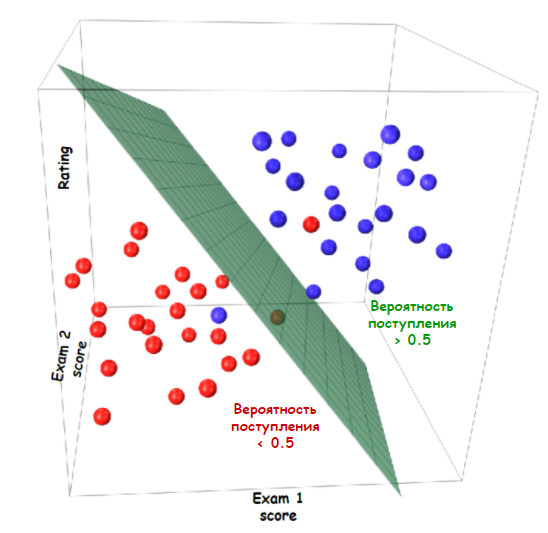

**Как подобрать коэффициенты в логистической регрессии?**

Идея применить метод наименьших квадратов кажется естественной, но на практике он плохо работает для классификации. Поэтому используется **метод максимального правдоподобия (MLE)** — мы ищем такие параметры модели, при которых наблюдаемые данные наиболее вероятны.

Максимизацию правдоподобия удобно заменить задачей минимизации, взяв отрицательный логарифм. В результате получается **функция логистических потерь**, также известная как *logloss* или *кросс-энтропия*:

$$
L(w) = -\sum_{i=1}^{n} \left( y_i \log \hat{P}_i + (1 - y_i)\log(1 - \hat{P}_i) \right) \rightarrow \min_w,
$$

где вероятность принадлежности к классу 1 вычисляется как

$$
\hat{P}*i = \frac{1}{1 + e^{-\left(w_0 + \sum*{j=1}^{m} w_j x_j\right)}}.
$$

Здесь:
- $n$ — число объектов,
- $y_i \in {0,1}$ — истинный класс,
- $\hat{P}_i$ — предсказанная моделью уверенность,
- $\log$ — натуральный логарифм.

Именно эту функцию мы минимизируем, подбирая параметры логистической регрессии.

Подробный вывод формул можно найти [здесь](https://habr.com/ru/articles/485872/).


**Напоминание о регуляризации**

Чтобы снизить риск переобучения, в функцию потерь логистической регрессии добавляют регуляризацию. В `sklearn` она реализована аналогично линейной регрессии, но с важным отличием в параметризации.

При **L1-регуляризации** к функции логистических потерь добавляется штраф, равный сумме модулей коэффициентов модели:

$$
L(w) = \text{logloss}(w) + \lambda \sum_{j=1}^{m} |w_j| \rightarrow \min_w
$$

где параметр регуляризации
$$
\lambda = \frac{1}{C}
$$

Здесь `C` — гиперпараметр `sklearn`, управляющий силой регуляризации: чем меньше `C`, тем сильнее регуляризация и тем сильнее модель штрафует большие значения коэффициентов.

Таким образом, регуляризация не изменяет форму функции logloss, а лишь добавляет к ней штраф за сложность модели.



При **L2-регуляризации** к функции потерь добавляется штраф за сумму квадратов коэффициентов:

$$
L(w) = \text{logloss}(w) + \lambda \sum_{j=1}^{m} w_j^2 \rightarrow \min_w.
$$



## 🟢 2. Бинарная классификация и баланс классов

Попробуем модель логистической регрессии на практике задачу для задачи бинарной классификации. В качестве экспериментальных данных используемуже знакомый набор данных о заболеваниях (1 - болен, 0 - нет).

In [72]:
#!pip install -q phik

In [73]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import cm
from matplotlib.colors import ListedColormap

from sklearn.datasets import load_breast_cancer, load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn import metrics

import phik
from phik.report import plot_correlation_matrix

In [74]:
data = load_breast_cancer()
df = pd.DataFrame(
    data=data.data,
    columns=data.feature_names
)
df['class'] = data.target

print(df.shape)
df.head()

(569, 31)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,class
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [75]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         569 non-null

In [76]:
df.describe()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,class
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


В датафрейме не совсем удобно обозначена целевая переменная (не как мы писали раньше), поменяем обозначения.



In [77]:
df['class'] = df['class'].replace({0: 1, 1: 0})
df['class'].value_counts()

class
0    357
1    212
Name: count, dtype: int64

### Баланс классов
**Несбалансированный** набор данных (unbalanced dataset) — это выборка, в которой количества объектов разных классов сильно различаются.

Это плохо, потому что:

* Модель смещается в сторону частого класса и плохо распознаёт редкий.
* Вероятности для редких классов занижены, ошибки на них случаются часто.
* Стандартные метрики, например точность (accuracy), могут вводить в заблуждение: высокая точность может скрывать плохое качество предсказаний для редкого класса.

Поэтому при работе с несбалансированными данными важно использовать специальные метрики и подходы к обучению.


**Что считается дисбалансом?** Ответ может варьироваться от умеренного до экстремального, как показано в таблице ниже.

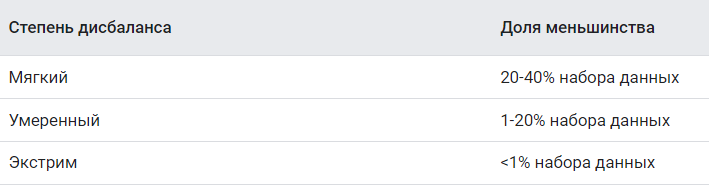

In [78]:
# в нашем датасете "мягкий" дисбаланс
df['class'].value_counts(normalize=True)

class
0    0.627417
1    0.372583
Name: proportion, dtype: float64

На практике существует ряд методов для исправления дисбаланса на уровне данных и обучения модели - про них мы поговорим на продвинутом семинаре.

Сейчас обсудим приём, который поможет по крайней мере честно выполнить оценку модели, обученной на несбалансированном датасете - речь про **разбиение выборок**.

> Чтобы уменьшить влияние дисбаланса классов, используют **стратифицированное разбиение (stratified split)**. Оно гарантирует, что пропорции классов сохраняются во всех подвыборках.


Для начала проведём обычное случайное разбиение на тренировочную и валидационную выборку (в соотношении 80/20) без стратификации:



In [79]:
X, y = df.drop('class', axis=1), df['class']
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=28)
print('Тренировочная выборка:\n', y_train.value_counts(normalize=True), sep='')
print('Тестовая выборка:\n', y_test.value_counts(normalize=True), sep='')

Тренировочная выборка:
class
0    0.615023
1    0.384977
Name: proportion, dtype: float64
Тестовая выборка:
class
0    0.664336
1    0.335664
Name: proportion, dtype: float64


Попробуем сбалансировать соотношения - достаточно в  `train_test_split()` задать параметр `stratify`, в который нужно передать столбец с метками классов.



In [80]:
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=28)
print('Тренировочная выборка:\n', y_train.value_counts(normalize=True), sep='')
print('Тестовая выборка:\n', y_test.value_counts(normalize=True), sep='')

Тренировочная выборка:
class
0    0.626761
1    0.373239
Name: proportion, dtype: float64
Тестовая выборка:
class
0    0.629371
1    0.370629
Name: proportion, dtype: float64


Традиционно посмотрим на матрицу корреляций и выберем наиболее коррелированные с целевым признаком факторы:



interval columns not set, guessing: ['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'mean smoothness', 'mean compactness', 'mean concavity', 'mean concave points', 'mean symmetry', 'mean fractal dimension', 'radius error', 'texture error', 'perimeter error', 'area error', 'smoothness error', 'compactness error', 'concavity error', 'concave points error', 'symmetry error', 'fractal dimension error', 'worst radius', 'worst texture', 'worst perimeter', 'worst area', 'worst smoothness', 'worst compactness', 'worst concavity', 'worst concave points', 'worst symmetry', 'worst fractal dimension', 'class']


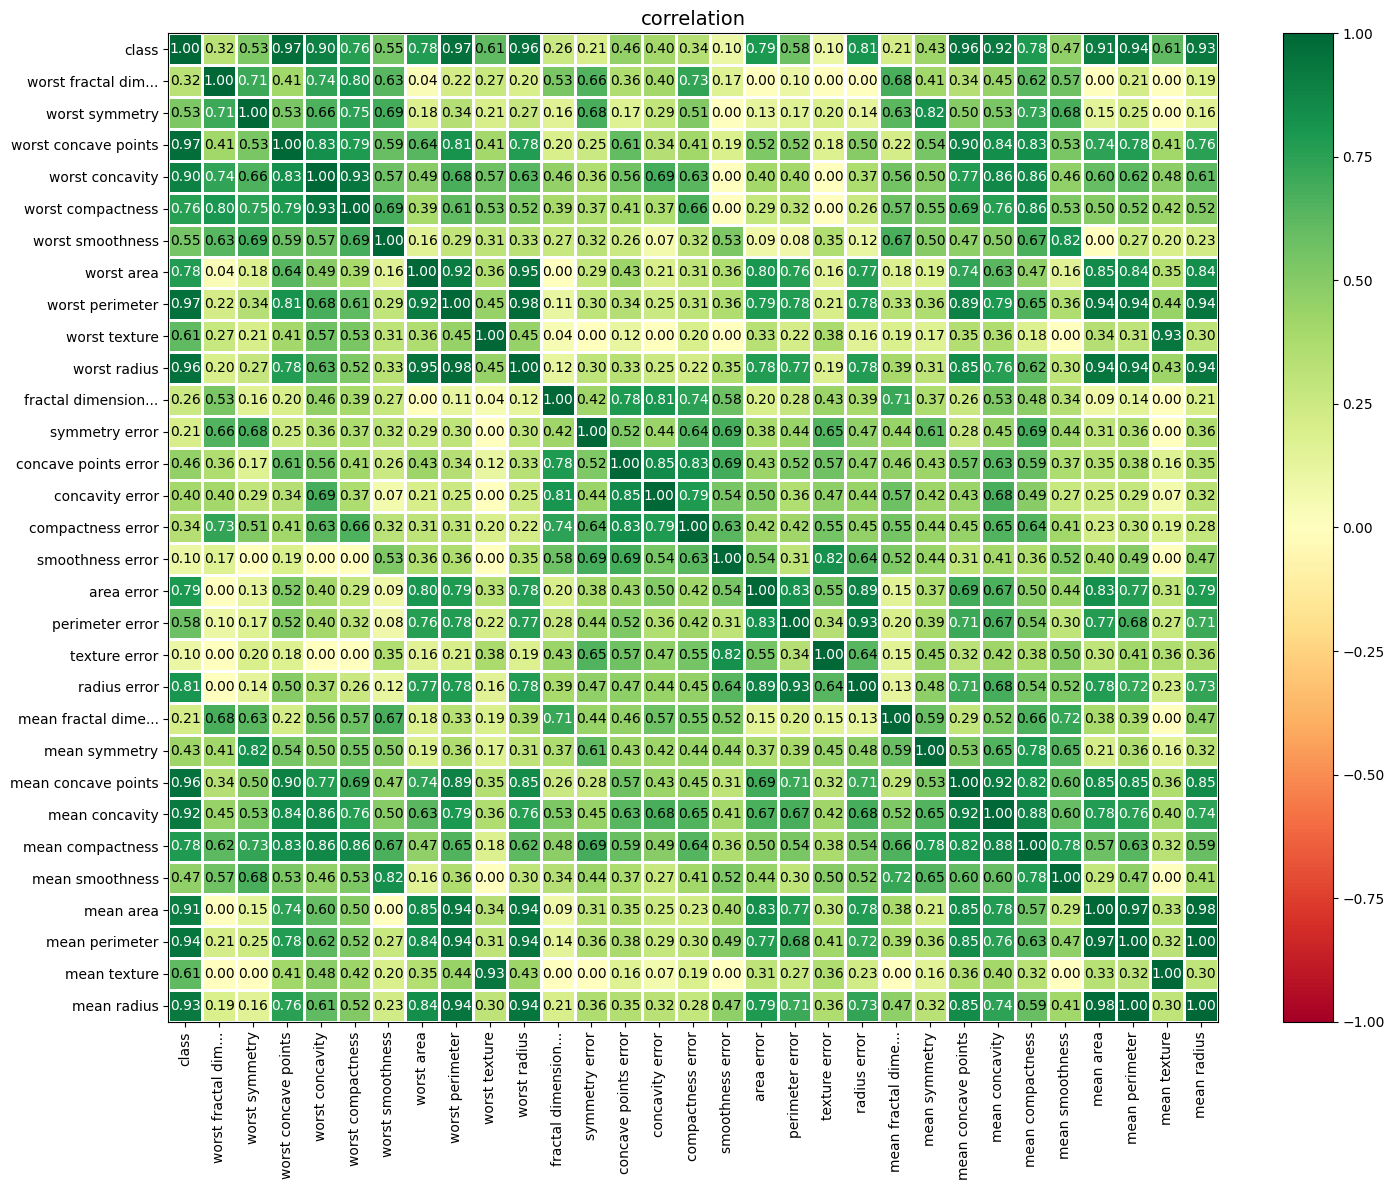

In [81]:
corr_matrix = df.phik_matrix()
plot_correlation_matrix(
    corr_matrix.values,
    x_labels=corr_matrix.columns,
    y_labels=corr_matrix.index,
    figsize=(15, 12)
)

In [82]:
target_corr = corr_matrix['class'].sort_values(ascending=False)
top_two_features = target_corr[1:3].index.tolist()

print("ТОП-2 признака с высокой корреляцией", top_two_features)

ТОП-2 признака с высокой корреляцией ['worst concave points', 'worst perimeter']


Построим диаграмму рассеяния, по оси абсцисс отложим фактор `worst concave points`, а по оси ординат — `worst perimeter`. Сделаем цветовую группировку по целевому значени:

<Axes: xlabel='worst concave points', ylabel='worst perimeter'>

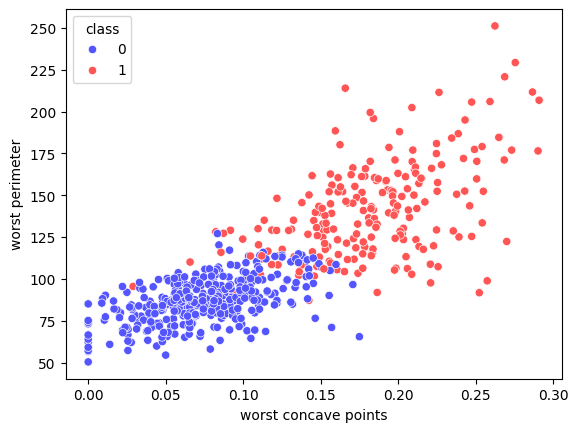

In [83]:
sns.scatterplot(
    data=df,
    x='worst concave points',
    y='worst perimeter',
    hue='class',
    palette='seismic'
)

Видим, что в разрезе этих двух признаков классы не сильно перемешаны. Попробуем построить разделяющую плоскость с помощью логистической регрессии.

Но прежде проведем стандартизацию.


In [84]:
scaler = StandardScaler()

X_train = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=df.drop('class', axis=1).columns
)
X_test = pd.DataFrame(
    scaler.transform(X_test),
    columns=df.drop('class', axis=1).columns
)

In [85]:
X_train_simple = X_train[top_two_features]
X_test_simple = X_test[top_two_features]
X_train_simple.head()

,worst concave points,worst perimeter
0,0.804620,-0.058556
1,0.012113,0.172687
2,-0.622987,-0.455319
3,-0.912322,-0.462926
4,-0.695047,-0.104196


Сначала реализуем базовую логистическую регрессию вручную.

In [86]:
class ManualLogistic:
    def __init__(self, lr=0.1, n_iter=1000):
        self.lr = lr
        self.n_iter = n_iter

    def sigmoid(self, z):
        # Какая формула у сигмоиды?
        return 1 / (1 + np.exp(-z))
    def fit(self, X, y):
        self.w = np.zeros(X.shape[1])
        self.b = 0
        for _ in range(self.n_iter):
            z = np.dot(X, self.w) + self.b
            h = self.sigmoid(z)
            grad_w = np.dot(X.T, (h - y)) / y.size
            grad_b = np.mean(h - y)
            # Сможете написать формулы градиентного спуска?
            self.w = self.w - self.lr * grad_w
            self.b = self.b - self.lr * grad_b


    def predict(self, X):
        return (self.sigmoid(np.dot(X, self.w) + self.b) >= 0.5).astype(int)

In [87]:
manual_log = ManualLogistic(lr=0.01, n_iter=1000)
manual_log.fit(X_train_simple, y_train)

y_pred_train_manual = manual_log.predict(X_train_simple)
y_pred_test_manual = manual_log.predict(X_test_simple)

print('Точность train:', metrics.accuracy_score(y_train, y_pred_train_manual))
print('Точность test:', metrics.accuracy_score(y_test, y_pred_test_manual))

Точность train: 0.9295774647887324
Точность test: 0.951048951048951


In [88]:
# коэффициенты
manual_log.w, manual_log.b

(array([1.26526889, 1.2997988 ]), np.float64(-0.5274702406379063))

**Теперь сравним с `LogisticRegression` из `sklearn`.**

Основные параметры логистической регресии:


1. `random_state` — число, на основе которого происходит генерация случайных чисел.
2. `penalty` — метод регуляризации. Возможные значения:  
    - `l1` — L1-регуляризация;  
    - `l2` — L2-регуляризация (используется по умолчанию);  
    - `elasticnet` — эластичная сетка (L1+L2);
    - `None` — отсутствие регуляризации.
3. `C` — коэффициент обратный коэффициенту регуляризации, то есть равен $1/\alpha$. Чем больше C, тем меньше регуляризация. По умолчанию `C=1`, тогда $\alpha=1$.
4. `solver` — численный метод оптимизации функции потерь `logloss`, может быть:
    - `'sag'` — стохастический градиентный спуск (нужна стандартизация/нормализация);
    - `'saga'` — [модификация](https://arxiv.org/pdf/1407.0202.pdf) предыдущего, которая поддерживает работу с негладкими функциями (нужна стандартизация/нормализация);
    - `'newton-cg'` — [метод Ньютона](https://docs.scipy.org/doc/scipy/tutorial/optimize.html#newton-conjugate-gradient-algorithm-method-newton-cg) с модификацией сопряжённых градиентов (не нужна стандартизация/нормализация);
    - `'lbfgs'` — [метод Бройдена — Флетчера — Гольдфарба — Шанно](https://ru.wikipedia.org/wiki/%D0%90%D0%BB%D0%B3%D0%BE%D1%80%D0%B8%D1%82%D0%BC_%D0%91%D1%80%D0%BE%D0%B9%D0%B4%D0%B5%D0%BD%D0%B0_%E2%80%94_%D0%A4%D0%BB%D0%B5%D1%82%D1%87%D0%B5%D1%80%D0%B0_%E2%80%94_%D0%93%D0%BE%D0%BB%D1%8C%D0%B4%D1%84%D0%B0%D1%80%D0%B1%D0%B0_%E2%80%94_%D0%A8%D0%B0%D0%BD%D0%BD%D0%BE) (не нужна стандартизация/нормализация; используется по умолчанию, так как из всех методов теоретически обеспечивает наилучшую сходимость);
    - `'liblinear'` — [метод покоординатного спуска](http://www.machinelearning.ru/wiki/index.php?title=%D0%9C%D0%B5%D1%82%D0%BE%D0%B4_%D0%BF%D0%BE%D0%BA%D0%BE%D0%BE%D1%80%D0%B4%D0%B8%D0%BD%D0%B0%D1%82%D0%BD%D0%BE%D0%B3%D0%BE_%D1%81%D0%BF%D1%83%D1%81%D0%BA%D0%B0) (не нужна стандартизация/нормализация).
5. `max_iter` — максимальное количество итераций, выделенных на сходимость.

In [89]:
sklearn_log = LogisticRegression(max_iter=1000, solver='lbfgs')
sklearn_log.fit(X_train_simple, y_train)

y_pred_train_sklearn = sklearn_log.predict(X_train_simple)
y_pred_test_sklearn = sklearn_log.predict(X_test_simple)

print('Точность train:', metrics.accuracy_score(y_train, y_pred_train_sklearn))
print('Точность test:', metrics.accuracy_score(y_test, y_pred_test_sklearn))

Точность train: 0.9366197183098591
Точность test: 0.965034965034965


In [90]:
# дополнительные метрики
print('precision train:', metrics.precision_score(y_train, y_pred_train_sklearn))
print('precision test:', metrics.precision_score(y_test, y_pred_test_sklearn))

print('recall train:', metrics.recall_score(y_train, y_pred_train_sklearn))
print('recall test:', metrics.recall_score(y_test, y_pred_test_sklearn))

print('f1 train:', metrics.f1_score(y_train, y_pred_train_sklearn))
print('f1 test:', metrics.f1_score(y_test, y_pred_test_sklearn))

precision train: 0.9125
precision test: 0.9615384615384616
recall train: 0.9182389937106918
recall test: 0.9433962264150944
f1 train: 0.9153605015673981
f1 test: 0.9523809523809523


In [91]:
sklearn_log.coef_, sklearn_log.intercept_

(array([[2.18531221, 3.24759618]]), array([-0.98072519]))

Теперь построим визуализацию нашей модели, оформив функцию `plot_probabilities_2d()`.

Она принимает три аргумента:

`X` — матрица с признаками,  
`y` — столбец с фактическими значениями.  
`model` — модель, с помощью которой делается предсказание вероятностей.

In [92]:
def plot_decision_boundary(X, y, model, resolution=0.01):
    # Преобразование Series в numpy массивы
    X = X.values
    y = y.values

    # Установливаем маркеры и цвета для классов
    markers = ('s', 'x')
    colors = ('r', 'b')
    cmap = ListedColormap(colors[:len(np.unique(y))])

    # Получаем границы признаков для построения координатной сетки
    x1_min, x1_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    x2_min, x2_max = X[:, 1].min() - 1, X[:, 1].max() + 1

    # Строим координатную сетку
    xx1, xx2 = np.meshgrid(
        np.linspace(x1_min, x1_max, int((x1_max - x1_min) / resolution)),
        np.linspace(x2_min, x2_max, int((x2_max - x2_min) / resolution))
    )

    # Получаем предсказанные вероятности для каждой точки на сетке
    Z = model.predict_proba(np.c_[xx1.ravel(), xx2.ravel()])[:, 1]
    Z = Z.reshape(xx1.shape)

    fig, ax = plt.subplots(figsize=(7, 5))

    # Риусем тепловую карту градиента вероятностей
    ax.contourf(xx1, xx2, Z, cmap=cm.coolwarm, alpha=0.8)

    # Рисуем разделяющую границу
    ax.contour(xx1, xx2, Z, [0.5], colors='k', linewidths=2)

    # Отрисовываем точки данных
    for i, label in enumerate(np.unique(y)):
        ax.scatter(
            X[y == label, 0], X[y == label, 1],
            c=colors[i], marker=markers[i],
            label=f'Class {label}', edgecolor='k'
        )

    # Добавляем легенду и названия осей
    ax.legend(loc='best')
    ax.set_xlabel('worst concave points')
    ax.set_ylabel('worst perimeter')

    plt.show()

d:\machine-learning\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
C:\Users\Alena\AppData\Local\Temp\ipykernel_1524\3267661610.py:35: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(


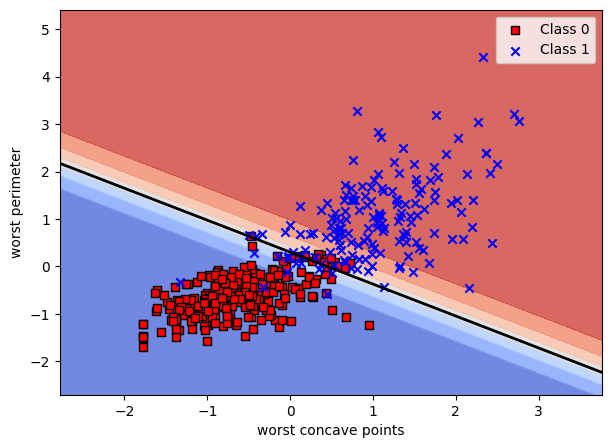

In [93]:
plot_decision_boundary(X_train_simple, y_train, sklearn_log)

## 🟢 3. Вероятностные оценки и подбор порога

Как сделать предсказание наличия заболевания более точно?

Метод `predict` возвращает жёсткие метки класса:

In [94]:
y_pred_test_sklearn

array([0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0,
       1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0,
       0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1,
       1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1,
       0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1,
       0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0])

Но можно получить вероятностные оценки напрямую и более точно подобрать порог, т.к. `predict()` автоматически применяет порог 0.5.

В этом поможет метод `predict_proba()`:

In [95]:
sklearn_log.predict_proba(X_test_simple)

array([[9.89457875e-01, 1.05421255e-02],
       [9.69868774e-01, 3.01312256e-02],
       [3.92859146e-03, 9.96071409e-01],
       [1.39467194e-01, 8.60532806e-01],
       [9.93186456e-01, 6.81354410e-03],
       [9.67590396e-01, 3.24096039e-02],
       [7.36063310e-01, 2.63936690e-01],
       [9.98225099e-01, 1.77490080e-03],
       [9.96694877e-01, 3.30512332e-03],
       [5.79117023e-01, 4.20882977e-01],
       [5.62416096e-08, 9.99999944e-01],
       [1.51251415e-06, 9.99998487e-01],
       [1.67355532e-02, 9.83264447e-01],
       [9.74503518e-01, 2.54964816e-02],
       [9.95336099e-01, 4.66390088e-03],
       [9.92465481e-01, 7.53451865e-03],
       [7.60554750e-02, 9.23944525e-01],
       [9.90580851e-01, 9.41914942e-03],
       [9.41257427e-01, 5.87425730e-02],
       [9.37073283e-01, 6.29267166e-02],
       [9.99683703e-01, 3.16297037e-04],
       [7.60690333e-01, 2.39309667e-01],
       [9.95000155e-01, 4.99984523e-03],
       [8.88579753e-01, 1.11420247e-01],
       [9.999017

Метод `predict_proba()` возвращает сразу две вероятности:
- первая соответствует вероятности принадлежности к классу 0 (здоров)
- вторая — вероятности принадлежности к классу 1 (болен).

В сумме две вероятности дают 1, что вполне логично, так как события взаимоисключающие.

---

Представим ситуацию, что обследование в клинике дорогое. Но при этом важно выявить как можно больше действительно больных людей - то есть важен и precision, и recall (можно менять "бизнем-требования").

Попробуем получить более высокие целевые метрики, подобрав более точный порог: для этого сделаем обычный перебор нескольких вариантов по сетке:

In [96]:
# Считаем вероятности наличия болезни для каждого пациента
# Нас интересует только вероятность 1-го класса (второй столбец)
y_proba_pred = sklearn_log.predict_proba(X_test_simple)[:, 1]

# Для удобства завернём numpy-массив в Pandas Series
y_proba_pred = pd.Series(y_proba_pred)

# Создадим списки, в которых будем хранить значения метрик
recall_scores = []
precision_scores = []
f1_scores = []

# Сгенерируем набор вероятностных порогов в диапазоне от 0.1 до 1
thresholds = np.arange(0.1, 1, 0.05)

# В цикле будем перебирать сгенерированные пороги
for threshold in thresholds:
    # Где вероятность болезни > threshold, относим к классу 1
    # В противном случае — к классу 0
    y_pred = y_proba_pred.apply(lambda x: 1 if x > threshold else 0)
    # Считаем метрики и добавляем их в списки
    recall_scores.append(metrics.recall_score(y_test, y_pred))
    precision_scores.append(metrics.precision_score(y_test, y_pred))
    f1_scores.append(metrics.f1_score(y_test, y_pred))

Построим графики зависимости метрик от порога вероятности:

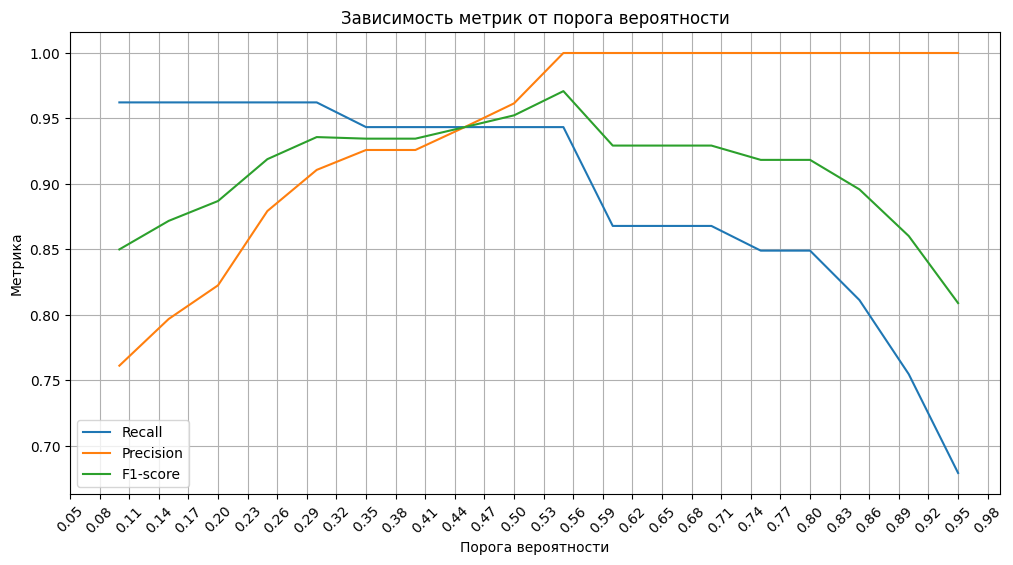

In [97]:
# Строим линейный график зависимости recall от threshold
plt.figure(figsize=(12, 6))
plt.plot(thresholds, recall_scores, label='Recall')
# Строим линейный график зависимости precision от threshold
plt.plot(thresholds, precision_scores, label='Precision')
# Строим линейный график зависимости F1 от threshold
plt.plot(thresholds, f1_scores, label='F1-score')

plt.title('Зависимость метрик от порога вероятности')
plt.xlabel('Порога вероятности')
plt.ylabel('Метрика')
plt.xticks(thresholds)
plt.xticks(np.arange(0.05, 1, 0.03), rotation=45)
plt.grid(True)
plt.legend()

С увеличением порога вероятности **precision растёт, а recall падает**. Модель начинает предсказывать «человек болен» только там, где уверена, повышая точность, но пропуская больных с низкой вероятностью, снижая охват.

Выбор порога зависит от того, какая метрика важнее - можно подобрать порог, при котором достигается максимизация целевой метрики.


In [98]:
best_threshold = thresholds[np.array(f1_scores).argmax()]
best_threshold

np.float64(0.5500000000000002)

In [99]:
y_pred_opt = y_proba_pred.map(
    lambda x: 1 if x > best_threshold else 0
)
print(metrics.classification_report(y_test, y_pred_opt))

              precision    recall  f1-score   support

           0       0.97      1.00      0.98        90
           1       1.00      0.94      0.97        53

    accuracy                           0.98       143
   macro avg       0.98      0.97      0.98       143
weighted avg       0.98      0.98      0.98       143



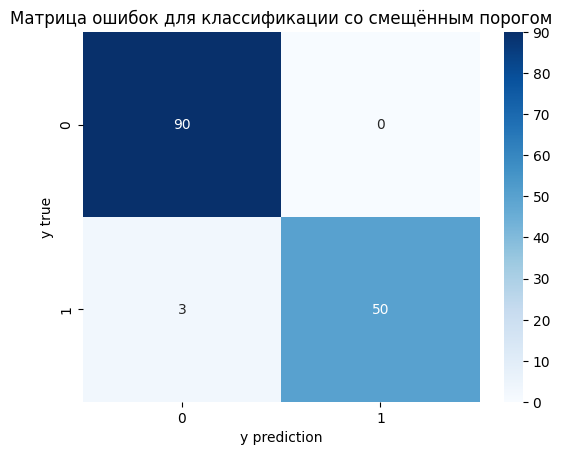

In [100]:
# построим красивую матрицу ошибок
sns.heatmap(
    metrics.confusion_matrix(y_test, y_pred_opt),
    annot=True, fmt='', cmap='Blues'
)
plt.title('Матрица ошибок для классификации со смещённым порогом')
plt.xlabel('y prediction')
plt.ylabel('y true')
plt.show()

## 🟢 4. Многоклассовая классификация и метрики

В бинарной логистической регрессии мы переводили линейную комбинацию признаков в вероятность через сигмоиду.

Для **многоклассовой задачи** строят линейную модель для каждого класса и преобразуют её выходы в вероятности с помощью **softmax**:

$$
\hat{P}_k = \text{softmax}(z_k) = \frac{\exp(\hat{y}_k)}{\sum_{j=1}^{K} \exp(\hat{y}_j)}
$$

Функция softmax возвращает нормированные вероятности, сумма которых по всем классам равна 1.

> PS: сигмоида - частный случай softmax для числа классов $K=2$.

Рассмотрим задачу многоклассовой классификации на примере классического датасета для **распознавание рукописных цифр**. Входные данные — изображения цифр, где каждый пиксель представлен интенсивностью. В датасете MNIST изображения имеют размер $8 \times 8$.

Загрузить их можно через `load_digits` из `sklearn`.

**Цель:** предсказать цифры по ее рукописному варианту.

Очевидно, что классификация является многоклассовой, возможных значений цифр (классов) 10.




In [101]:
X, y = load_digits(return_X_y=True)
X[0]

array([ 0.,  0.,  5., 13.,  9.,  1.,  0.,  0.,  0.,  0., 13., 15., 10.,
       15.,  5.,  0.,  0.,  3., 15.,  2.,  0., 11.,  8.,  0.,  0.,  4.,
       12.,  0.,  0.,  8.,  8.,  0.,  0.,  5.,  8.,  0.,  0.,  9.,  8.,
        0.,  0.,  4., 11.,  0.,  1., 12.,  7.,  0.,  0.,  2., 14.,  5.,
       10., 12.,  0.,  0.,  0.,  0.,  6., 13., 10.,  0.,  0.,  0.])

Класс: 0


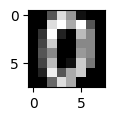

In [102]:
print('Класс:', y[0])
plt.figure(figsize=(1, 1))
plt.imshow(X[0].reshape(8, 8), cmap='gray')
plt.show()

In [103]:
pd.Series(y).value_counts()

3    183
1    182
5    182
4    181
6    181
9    180
7    179
0    178
2    177
8    174
Name: count, dtype: int64

In [104]:
X_train, X_test, y_train, y_test = train_test_split(X, y, shuffle=True)

# предобработка
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# обучение модели
clf = LogisticRegression()
clf.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [105]:
metrics.accuracy_score(y_test, clf.predict(X_test))

0.9733333333333334

В `classification_report` для многоклассовой классификации просто добавляется новая строка, соответствующие всем классам.


In [106]:
print(metrics.classification_report(y_test, clf.predict(X_test)))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        52
           1       0.93      0.96      0.95        45
           2       1.00      1.00      1.00        43
           3       0.98      0.95      0.96        56
           4       1.00      0.97      0.99        37
           5       0.96      0.98      0.97        53
           6       1.00      0.97      0.99        36
           7       0.96      1.00      0.98        44
           8       0.96      0.96      0.96        47
           9       0.95      0.95      0.95        37

    accuracy                           0.97       450
   macro avg       0.97      0.97      0.97       450
weighted avg       0.97      0.97      0.97       450



И посмотрим на матрицу ошибок

<Axes: >

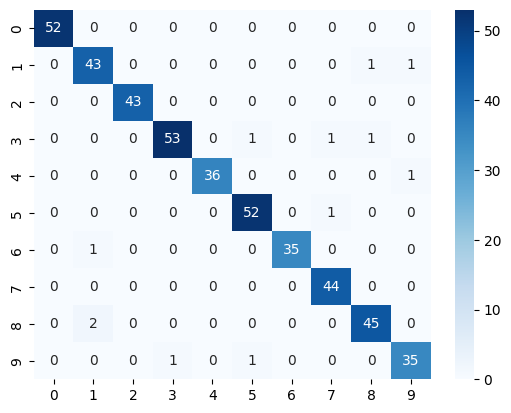

In [107]:
conf_matrix = metrics.confusion_matrix(y_test, clf.predict(X_test))
sns.heatmap(conf_matrix, annot=True, fmt='', cmap='Blues')

Но такие метрики, как точность, precision, recall и F1 можно считать по-разному:

* **Macro-averaging** — усреднение метрик по классам, каждый класс равен:

$$
\text{Precision}_{macro} = \frac{1}{K} \sum_{k=1}^{K} \text{Precision}_k, \quad
\text{Recall}_{macro} = \frac{1}{K} \sum_{k=1}^{K} \text{Recall}_k
$$

* **Micro-averaging** — усреднение метрик через суммирование всех TP, FP, FN:

$$
\text{Precision}_{micro} = \frac{\sum_k TP_k}{\sum_k TP_k + \sum_k FP_k}, \quad
\text{Recall}_{micro} = \frac{\sum_k TP_k}{\sum_k TP_k + \sum_k FN_k}
$$

* **F1-score** можно считать через среднее макро или микро:

$$
F1 = 2 \cdot \frac{\text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}}
$$

**Интерпретация:**

* Macro показывает равновесие качества по всем классам.
* Micro чувствителен к частым классам.

Это помогает выбирать метрику в зависимости от того, важен ли редкий класс или общее качество модели.
